In [1]:
!pip -q install torch torchvision matplotlib

import torch
import torch.nn as nn
import torchvision.utils as vutils
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()

        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 256, 4, 1, 0),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)


z_dim = 100
generator = Generator(z_dim).to(device)

for m in generator.modules():
    if isinstance(m, nn.ConvTranspose2d):
        nn.init.normal_(m.weight, 0.0, 0.02)

generator.eval()

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): Tanh()
  )
)

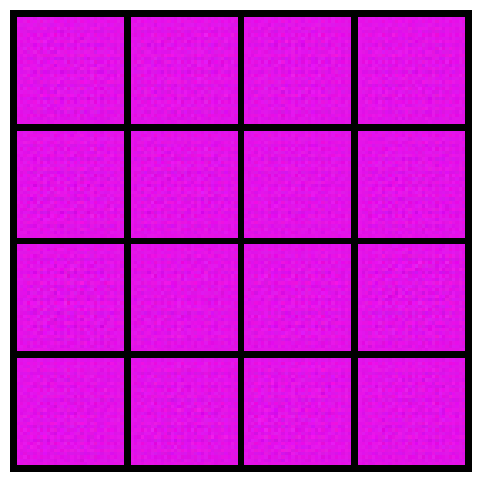

In [6]:
noise = torch.randn(16, z_dim, 1, 1).to(device)

with torch.no_grad():
    fake_images = generator(noise).cpu()

grid = vutils.make_grid(fake_images, nrow=4, normalize=True)

plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1,2,0))
plt.axis("off")

plt.savefig("gan_random_samples.png", dpi=300, bbox_inches="tight")
plt.show()

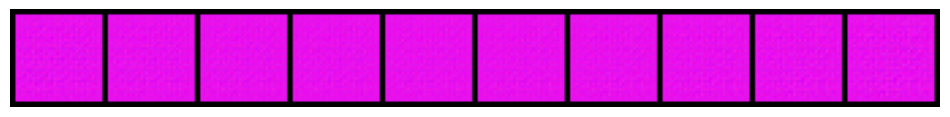

In [7]:
z1 = torch.randn(1, z_dim, 1, 1).to(device)
z2 = torch.randn(1, z_dim, 1, 1).to(device)

interpolated = []

steps = 10
for alpha in torch.linspace(0,1,steps):
    z = (1-alpha)*z1 + alpha*z2
    with torch.no_grad():
        img = generator(z).cpu()
    interpolated.append(img)

interpolated = torch.cat(interpolated, dim=0)

grid = vutils.make_grid(interpolated, nrow=10, normalize=True)

plt.figure(figsize=(12,3))
plt.imshow(grid.permute(1,2,0))
plt.axis("off")

plt.savefig("gan_interpolation.png", dpi=300, bbox_inches="tight")
plt.show()